# Health Indicators ETL Pipeline — Africa
Analysis of World Bank health data across 54 African countries.
**Pipeline:** Extract → Transform → Load → Analyze
**Data source:** World Bank Health Nutrition and Population Statistics(Kaggle)

In [1]:
# Imports
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

## 1. Extract
Download the dataset from Kaggle and load it into a DataFrame.

In [2]:
#Download dataset from kaggle
api = KaggleApi()
api.authenticate()

api.dataset_download_file(
    'theworldbank/health-nutrition-and-population-statistics',
    file_name='data.csv',
    path='.'
)

Dataset URL: https://www.kaggle.com/datasets/theworldbank/health-nutrition-and-population-statistics


False

In [3]:
#extract file from zipfile
zip_ref= zipfile.ZipFile('data.csv.zip')
zip_ref.extractall() #extract file to dir
zip_ref.close() #close file

In [4]:
#read the data from the file and handle null values
df = pd.read_csv('data.csv')
#df.head(20) #Pour voir les 20 premières lignes
#df['1961'].unique() #montre les différentes valeurs que peut prendre les éléments d'une colonne
#Si on avait unavailabe, ou unknown, on fait na_values=[ 'unknown' ,...] lors de transform


## 2. Transform
Restructure, clean and filter the data to keep only African countries and relevant indicators.

In [5]:
#we rename columns names, we make them lower case and replace space with underscore
#df.rename(columns={'Country Code' : 'country_code' , 'Country Name' : 'country_name'}) But we can't do this pour chaque colonne 
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ', '_' )
df.head(5)

,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,unnamed:_60
0,Arab World,ARB,% of females ages 15-49 having comprehensive c...,SH.HIV.KNOW.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,% of males ages 15-49 having comprehensive cor...,SH.HIV.KNOW.MA.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,133.555013,134.159119,134.857912,134.504576,134.105211,133.569626,...,49.999851,49.887046,49.781207,49.672975,49.536047,49.383745,48.796558,48.196418,NaN,NaN
3,Arab World,ARB,Adults (ages 15+) and children (0-14 years) li...,SH.HIV.TOTL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,Adults (ages 15+) and children (ages 0-14) new...,SH.HIV.INCD.TL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#On transforme le datset en formant long
df = df.melt(
    id_vars=['country_name', 'country_code', 'indicator_name', 'indicator_code'], #ces valeurs ne changent pas
    var_name='year', #la nouvele variable qui prend les valeurs des colonnes années
    value_name='value' # les valeurs des colonnes années vont dans une nouvelle colonne de nom value 
)

In [7]:
df.head()

,country_name,country_code,indicator_name,indicator_code,year,value
0,Arab World,ARB,% of females ages 15-49 having comprehensive c...,SH.HIV.KNOW.FE.ZS,1960,NaN
1,Arab World,ARB,% of males ages 15-49 having comprehensive cor...,SH.HIV.KNOW.MA.ZS,1960,NaN
2,Arab World,ARB,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,133.555013
3,Arab World,ARB,Adults (ages 15+) and children (0-14 years) li...,SH.HIV.TOTL,1960,NaN
4,Arab World,ARB,Adults (ages 15+) and children (ages 0-14) new...,SH.HIV.INCD.TL,1960,NaN


In [8]:
print(df.shape)
print(df.head())
print(df.dtypes) 

(5073570, 6)
  country_name country_code  \
0   Arab World          ARB   
1   Arab World          ARB   
2   Arab World          ARB   
3   Arab World          ARB   
4   Arab World          ARB   

                                      indicator_name     indicator_code  year  \
0  % of females ages 15-49 having comprehensive c...  SH.HIV.KNOW.FE.ZS  1960   
1  % of males ages 15-49 having comprehensive cor...  SH.HIV.KNOW.MA.ZS  1960   
2  Adolescent fertility rate (births per 1,000 wo...        SP.ADO.TFRT  1960   
3  Adults (ages 15+) and children (0-14 years) li...        SH.HIV.TOTL  1960   
4  Adults (ages 15+) and children (ages 0-14) new...     SH.HIV.INCD.TL  1960   

        value  
0         NaN  
1         NaN  
2  133.555013  
3         NaN  
4         NaN  
country_name       object
country_code       object
indicator_name     object
indicator_code     object
year               object
value             float64
dtype: object


In [9]:
#Type de year= object on change ça en numeric vu que l'on a que les années, si on avait date complète, on fait to_datetime()
#df.dtypes
df['year'] = pd.to_numeric(df['year'], errors='coerce') #coerce permet de transformer les valeurs bizarres en Nan et continuer 

In [10]:
df.dtypes

country_name       object
country_code       object
indicator_name     object
indicator_code     object
year              float64
value             float64
dtype: object

In [11]:
#On supprime les lignes qui ont des NaN ici car il y en a beaucoup
df_clean = df.dropna(subset=['value'])
print(df_clean.shape)

(2476042, 6)


In [12]:
df_clean

,country_name,country_code,indicator_name,indicator_code,year,value
2,Arab World,ARB,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960.0,1.335550e+02
9,Arab World,ARB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960.0,8.779923e+01
10,Arab World,ARB,"Age dependency ratio, old",SP.POP.DPND.OL,1960.0,6.635328e+00
11,Arab World,ARB,"Age dependency ratio, young",SP.POP.DPND.YG,1960.0,8.102425e+01
68,Arab World,ARB,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,1960.0,4.769972e+01
...,...,...,...,...,...,...
4984519,Zimbabwe,ZWE,Rural population growth (annual %),SP.RUR.TOTL.ZG,2015.0,2.498968e+00
4984550,Zimbabwe,ZWE,Urban population,SP.URB.TOTL,2015.0,5.051547e+06
4984551,Zimbabwe,ZWE,Urban population (% of total),SP.URB.TOTL.IN.ZS,2015.0,3.237600e+01
4984552,Zimbabwe,ZWE,Urban population growth (annual %),SP.URB.GROW,2015.0,1.928627e+00


In [13]:
#On considère que les pays africains
pays_afrique = [
    'DZA', 'AGO', 'BEN', 'BWA', 'BFA', 'BDI', 'CPV', 'CMR', 'CAF', 'TCD',
    'COM', 'COD', 'COG', 'CIV', 'DJI', 'EGY', 'GNQ', 'ERI', 'SWZ', 'ETH',
    'GAB', 'GMB', 'GHA', 'GIN', 'GNB', 'KEN', 'LSO', 'LBR', 'LBY', 'MDG',
    'MWI', 'MLI', 'MRT', 'MUS', 'MAR', 'MOZ', 'NAM', 'NER', 'NGA', 'RWA',
    'STP', 'SEN', 'SLE', 'SOM', 'ZAF', 'SSD', 'SDN', 'TZA', 'TGO', 'TUN',
    'UGA', 'ZMB', 'ZWE', 'SYC'
]

df_afrique = df_clean[df_clean['country_code'].isin(pays_afrique)]
print(df_afrique.shape)

(614407, 6)


In [14]:
df_afrique 

,country_name,country_code,indicator_name,indicator_code,year,value
14837,Algeria,DZA,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960.0,1.238892e+02
14844,Algeria,DZA,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960.0,9.142517e+01
14845,Algeria,DZA,"Age dependency ratio, old",SP.POP.DPND.OL,1960.0,6.166136e+00
14846,Algeria,DZA,"Age dependency ratio, young",SP.POP.DPND.YG,1960.0,8.525903e+01
14847,Algeria,DZA,"Age population, age 0, female, interpolated",SP.POP.AG00.FE.IN,1960.0,2.137640e+05
...,...,...,...,...,...,...
4984519,Zimbabwe,ZWE,Rural population growth (annual %),SP.RUR.TOTL.ZG,2015.0,2.498968e+00
4984550,Zimbabwe,ZWE,Urban population,SP.URB.TOTL,2015.0,5.051547e+06
4984551,Zimbabwe,ZWE,Urban population (% of total),SP.URB.TOTL.IN.ZS,2015.0,3.237600e+01
4984552,Zimbabwe,ZWE,Urban population growth (annual %),SP.URB.GROW,2015.0,1.928627e+00


## 3. Load
Store the cleaned data into a SQLite database.

In [15]:
#Charger les données dans SQLite=base de données légère intégrée à Python
#sqlite3=module python natif pour se connecter à SQLite

# Créer la connexion à la base de données
conn = sqlite3.connect("sante_afrique.db")

# Charger le dataframe dans SQLite
#indicateurs_sante=nom de la table
df_afrique.to_sql("indicateurs_sante", conn, if_exists="replace", index=False)

print("Données chargées avec succès !")

Données chargées avec succès !


In [16]:
# Voir tous les indicateurs disponibles
indicateurs = pd.read_sql("SELECT DISTINCT indicator_name FROM indicateurs_sante", conn)
print(indicateurs)

                                        indicator_name
0    Adolescent fertility rate (births per 1,000 wo...
1    Age dependency ratio (% of working-age populat...
2                            Age dependency ratio, old
3                          Age dependency ratio, young
4          Age population, age 0, female, interpolated
..                                                 ...
340  Number of surgical procedures (per 100,000 pop...
341  Mortality caused by road traffic injury (per 1...
342  Risk of catastrophic expenditure for surgical ...
343  Risk of impoverishing expenditure for surgical...
344  Diabetes prevalence (% of population ages 20 t...

[345 rows x 1 columns]


In [17]:
#Exporter les indicateurs dans un fichier afin de choisir sur lesquels étudier
indicateurs.to_csv("liste_indicateurs.csv", index=False)

In [18]:
#étude sur les indicateurs suivants
indicateurs_choisis = [
    'Life expectancy at birth, total (years)',
    'Mortality rate, infant (per 1,000 live births)',
    'Improved water source (% of population with access)',
    'Health expenditure per capita (current US$)'
]

df_final = df_afrique[df_afrique['indicator_name'].isin(indicateurs_choisis)] # En vrai ici on crée une fenêtre(vue) de df_afrique
#donc df_final dépend de df_afrique
print(df_final.shape)
print(df_final['indicator_name'].value_counts())

(7910, 6)
indicator_name
Life expectancy at birth, total (years)                2877
Mortality rate, infant (per 1,000 live births)         2708
Improved water source (% of population with access)    1310
Health expenditure per capita (current US$)            1015
Name: count, dtype: int64


In [19]:
#On avait type de year=float64 pour pouvoir faire les requêtes SQL on le met en int64 
df_final = df_final.copy()  #  df_final est vraiment indépendant maintenant de df_afrique et n'est plus une simple vue
df_final['year'] = df_final['year'].astype(int) 

In [20]:
df_final.dtypes

country_name       object
country_code       object
indicator_name     object
indicator_code     object
year                int64
value             float64
dtype: object

In [21]:
#on remplace la dataset que l'on avait avec la dataset ne contenant que les indicateurs que nous souhaitons traiter
df_final.to_sql("indicateurs_sante", conn, if_exists="replace", index=False)
print("Données finales chargées !")

Données finales chargées !


## 4. Analysis — African Overview (2014)
SQL queries and visualizations comparing health indicators across African countries.

In [22]:
#Les 10 pays avec l'espérance de vie la plus élevée en 2014, du plus grand au plus petit
query1 = """
SELECT country_name, value
FROM indicateurs_sante
WHERE indicator_name = 'Life expectancy at birth, total (years)'
AND year = 2014
ORDER BY value DESC
LIMIT 10
"""

df_query1 = pd.read_sql(query1, conn)
print(df_query1)

            country_name      value
0                Algeria  74.808098
1              Mauritius  74.194390
2                Tunisia  74.143902
3                Morocco  74.016098
4             Seychelles  73.229268
5             Cabo Verde  73.147000
6                  Libya  71.716122
7       Egypt, Arab Rep.  71.121707
8  Sao Tome and Principe  66.384610
9                Senegal  66.372585


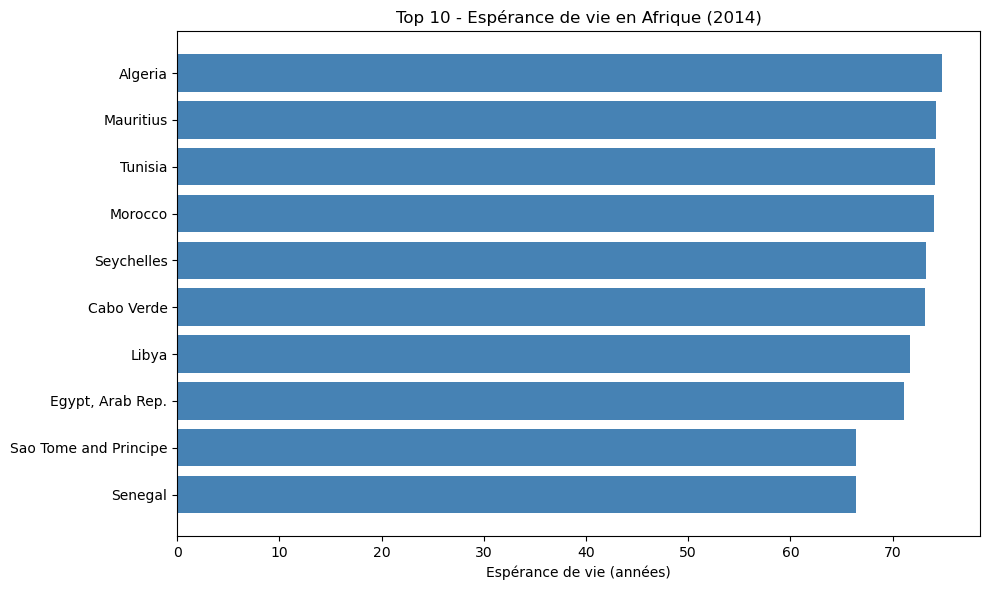

In [23]:
#On visualise le résultat 
plt.figure(figsize=(10, 6))
plt.barh(df_query1['country_name'], df_query1['value'], color='steelblue')
plt.xlabel("Espérance de vie (années)")
plt.title("Top 10 - Espérance de vie en Afrique (2014)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
query2 = """
SELECT country_name, value
FROM indicateurs_sante
WHERE indicator_name = 'Mortality rate, infant (per 1,000 live births)'
AND year = 2014
ORDER BY value DESC
LIMIT 10
"""
df_query2 = pd.read_sql(query2, conn)
print(df_query2)

               country_name  value
0                    Angola   98.8
1  Central African Republic   93.5
2              Sierra Leone   90.2
3                   Somalia   87.4
4                      Chad   86.7
5                      Mali   75.9
6                   Nigeria   71.5
7                   Lesotho   70.5
8         Equatorial Guinea   70.3
9             Cote d'Ivoire   68.5


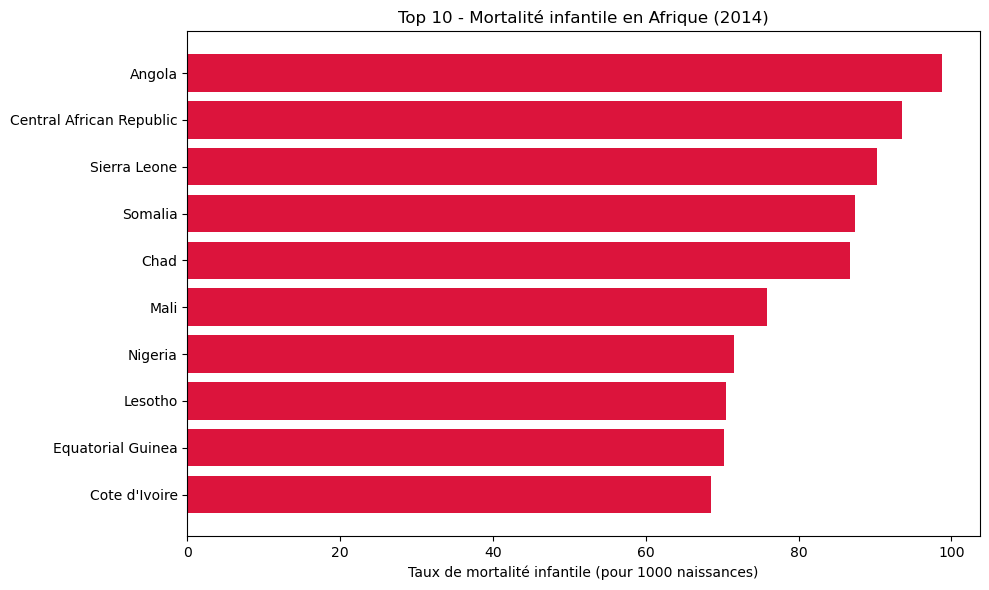

In [25]:
#On visualise le résultat
plt.figure(figsize=(10, 6))
plt.barh(df_query2['country_name'], df_query2['value'], color='crimson')
plt.xlabel("Taux de mortalité infantile (pour 1000 naissances)")
plt.title("Top 10 - Mortalité infantile en Afrique (2014)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
query3 = """
SELECT country_name, value
FROM indicateurs_sante
WHERE indicator_name = 'Improved water source (% of population with access)'
AND year = 2014
ORDER BY value ASC
LIMIT 10
"""
df_query3 = pd.read_sql(query3, conn)
print(df_query3)

        country_name  value
0  Equatorial Guinea   47.8
1             Angola   48.6
2         Madagascar   50.6
3               Chad   50.8
4         Mozambique   50.9
5           Ethiopia   55.4
6              Sudan   55.5
7           Tanzania   55.5
8            Eritrea   57.7
9         Mauritania   57.9


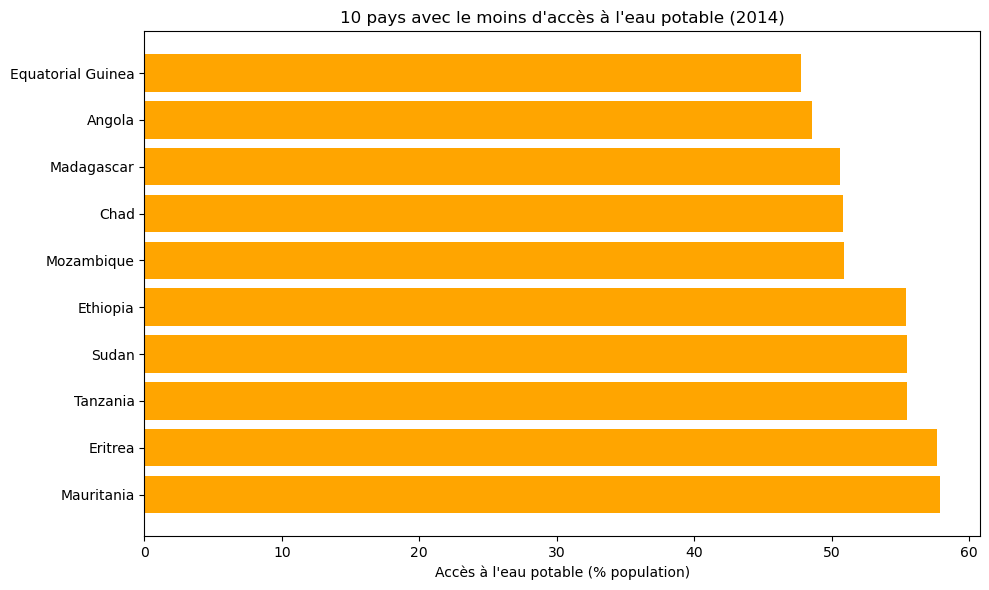

In [27]:
#On visualise le résultat
plt.figure(figsize=(10, 6))
plt.barh(df_query3['country_name'], df_query3['value'], color='orange')
plt.xlabel("Accès à l'eau potable (% population)")
plt.title("10 pays avec le moins d'accès à l'eau potable (2014)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [28]:
query4 = """
SELECT country_name, value
FROM indicateurs_sante
WHERE indicator_name = 'Health expenditure per capita (current US$)'
AND year = 2014
ORDER BY value DESC
LIMIT 10
"""
df_query4 = pd.read_sql(query4, conn)
print(df_query4)

        country_name       value
0  Equatorial Guinea  663.054229
1       South Africa  570.206074
2            Namibia  499.015684
3         Seychelles  494.128284
4          Mauritius  482.454173
5           Botswana  385.314097
6              Libya  371.721870
7            Algeria  361.729174
8              Gabon  321.330091
9            Tunisia  305.305519


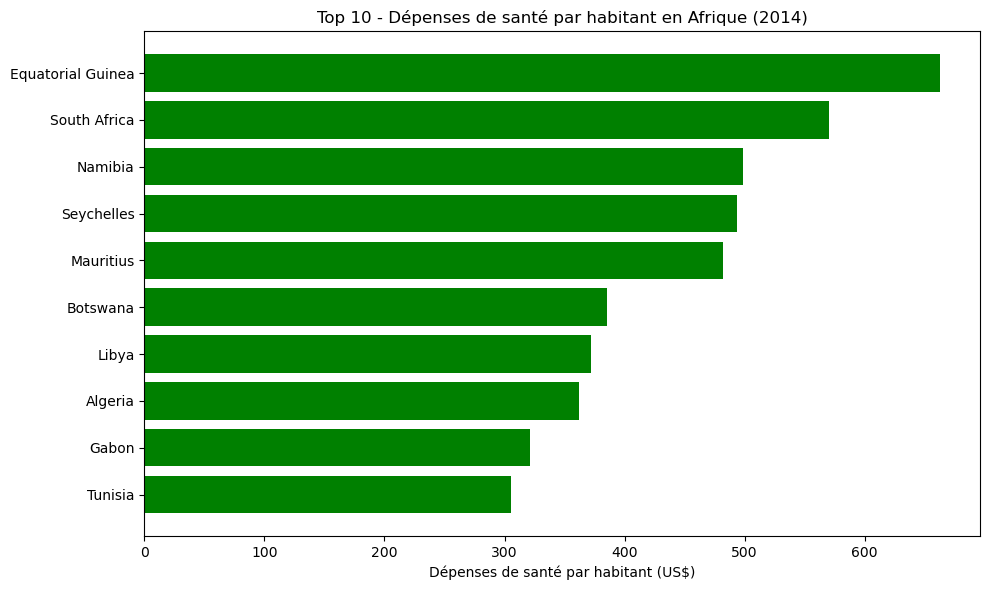

In [29]:
#On visualise le résultat
plt.figure(figsize=(10, 6))
plt.barh(df_query4['country_name'], df_query4['value'], color='green')
plt.xlabel("Dépenses de santé par habitant (US$)")
plt.title("Top 10 - Dépenses de santé par habitant en Afrique (2014)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Focus — Senegal (2000-2014)
Evolution of key health indicators in Senegal over time.

In [30]:
query_senegal = """
SELECT year, value
FROM indicateurs_sante
WHERE indicator_name = 'Life expectancy at birth, total (years)'
AND country_code = 'SEN'
AND year BETWEEN 2000 AND 2014
ORDER BY year
"""
df_senegal = pd.read_sql(query_senegal, conn)
print(df_senegal)

    year      value
0   2000  57.765805
1   2001  58.135561
2   2002  58.596171
3   2003  59.127683
4   2004  59.718512
5   2005  60.361927
6   2006  61.054073
7   2007  61.784171
8   2008  62.535073
9   2009  63.286780
10  2010  64.014439
11  2011  64.695366
12  2012  65.318878
13  2013  65.878756
14  2014  66.372585


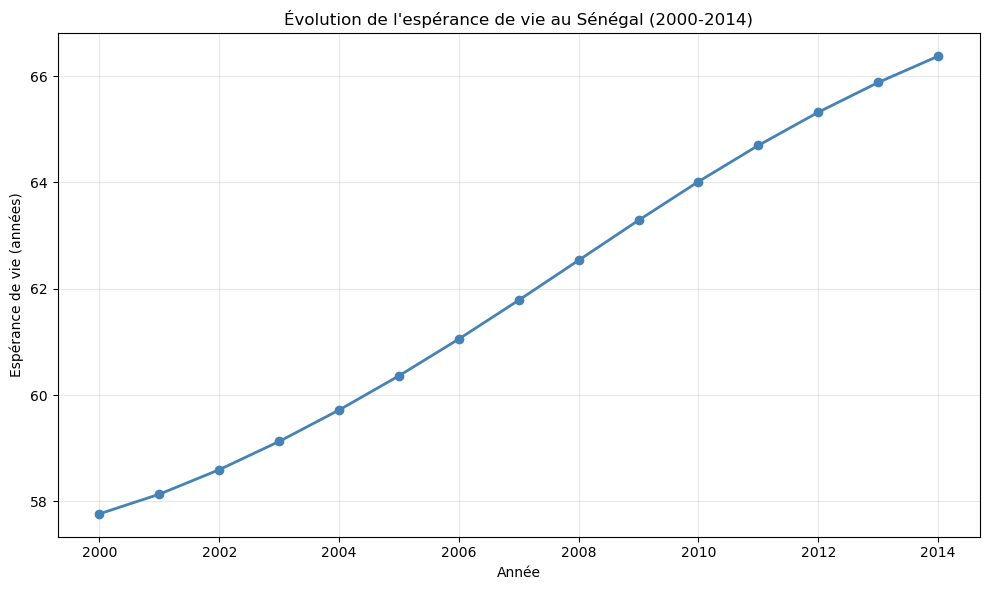

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(df_senegal['year'], df_senegal['value'], 
         color='steelblue', marker='o', linewidth=2)
plt.xlabel("Année")
plt.ylabel("Espérance de vie (années)")
plt.title("Évolution de l'espérance de vie au Sénégal (2000-2014)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
query_senegal2 = """
SELECT year, value
FROM indicateurs_sante
WHERE indicator_name = 'Mortality rate, infant (per 1,000 live births)'
AND country_code = 'SEN'
AND year BETWEEN 2000 AND 2014
ORDER BY year
"""
df_senegal2 = pd.read_sql(query_senegal2, conn)
print(df_senegal2)


    year  value
0   2000   68.5
1   2001   66.4
2   2002   63.9
3   2003   61.3
4   2004   58.8
5   2005   56.3
6   2006   54.0
7   2007   51.9
8   2008   50.0
9   2009   48.3
10  2010   46.7
11  2011   45.3
12  2012   44.1
13  2013   43.1
14  2014   42.3


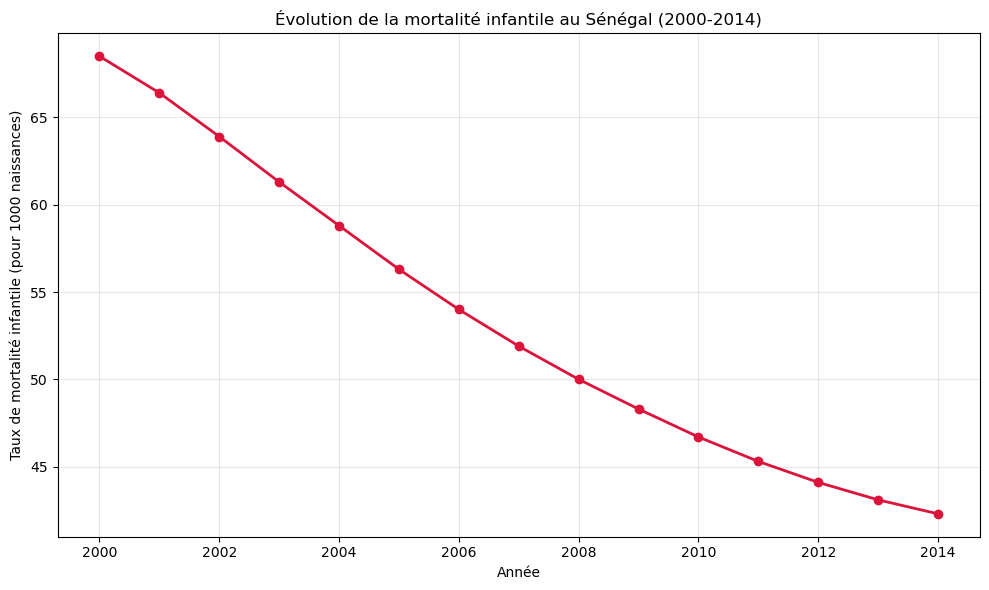

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(df_senegal2['year'], df_senegal2['value'], 
         color='crimson', marker='o', linewidth=2)
plt.xlabel("Année")
plt.ylabel("Taux de mortalité infantile (pour 1000 naissances)")
plt.title("Évolution de la mortalité infantile au Sénégal (2000-2014)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Key Insights
- Algeria has the highest life expectancy in Africa (74.8 years in 2014)
- Senegal's life expectancy increased by +8.6 years between 2000 and 2014
- Infant mortality in Senegal dropped by nearly 40% between 2000 and 2014